In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, json, re
import numpy as np
import pandas as pd
from scipy import stats
from scipy.fft import rfft, rfftfreq
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option('display.max_colwidth', 120)
print("Libraries loaded.")


Mounted at /content/drive
Libraries loaded.


## Part 1 — Data Discovery
Point this at your `SENSOR DATASET/data/ortho/KOA` folder in Drive and print the tree so we know exactly what we're working with.


In [ ]:
KOA_ROOT = "/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA"  # adjust if your path differs

def print_tree(root, max_depth=4, max_items=15):
    root = root.rstrip("/")
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath)}/")
        for f in sorted(filenames)[:max_items]:
            print(f"{indent}  {f}")
        if len(filenames) > max_items:
            print(f"{indent}  ... ({len(filenames) - max_items} more files)")

print_tree(KOA_ROOT)


KOA/
  KOA_8/
    KOA_8_2/
      KOA_8_2_meta.json
      KOA_8_2_plot.png
      KOA_8_2_processed_data.txt
      KOA_8_2_raw_data_HE.txt
      KOA_8_2_raw_data_LB.txt
      KOA_8_2_raw_data_LF.txt
      KOA_8_2_raw_data_RF.txt
    KOA_8_1/
      KOA_8_1_meta.json
      KOA_8_1_plot.png
      KOA_8_1_processed_data.txt
      KOA_8_1_raw_data_HE.txt
      KOA_8_1_raw_data_LB.txt
      KOA_8_1_raw_data_LF.txt
      KOA_8_1_raw_data_RF.txt
  KOA_1/
    KOA_1_1/
      KOA_1_1_meta.json
      KOA_1_1_plot.png
      KOA_1_1_processed_data.txt
      KOA_1_1_raw_data_HE.txt
      KOA_1_1_raw_data_LB.txt
      KOA_1_1_raw_data_LF.txt
      KOA_1_1_raw_data_RF.txt
    KOA_1_5/
      KOA_1_5_meta.json
      KOA_1_5_plot.png
      KOA_1_5_processed_data.txt
      KOA_1_5_raw_data_HE.txt
      KOA_1_5_raw_data_LB.txt
      KOA_1_5_raw_data_LF.txt
      KOA_1_5_raw_data_RF.txt
    KOA_1_2/
      KOA_1_2_meta.json
      KOA_1_2_plot.png
      KOA_1_2_processed_data.txt
      KOA_1_2_raw_data_HE.txt
  

In [ ]:
# Grab one JSON metadata file and one sensor data file so we can see actual keys/columns.
json_candidates = sorted(glob.glob(os.path.join(KOA_ROOT, "**", "*.json"), recursive=True))
csv_candidates  = sorted(glob.glob(os.path.join(KOA_ROOT, "**", "*.csv"), recursive=True) +
                          glob.glob(os.path.join(KOA_ROOT, "**", "*.txt"), recursive=True))

print(f"Found {len(json_candidates)} JSON files, {len(csv_candidates)} CSV/TXT files\n")

if json_candidates:
    print("--- Sample metadata file:", json_candidates[0], "---")
    with open(json_candidates[0]) as f:
        print(json.dumps(json.load(f), indent=2)[:1500])
else:
    print("No JSON metadata files found under KOA_ROOT — check the path/tree above.")


Found 78 JSON files, 390 CSV/TXT files

--- Sample metadata file: /content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_1/KOA_1_1/KOA_1_1_meta.json ---
{
  "subject": "KOA_1",
  "age": 60,
  "gender": "F",
  "height": 1.5,
  "weight": 63.0,
  "BMI": 28.0,
  "laterality": "right",
  "group": "ortho",
  "pathology": "knee osteoarthritis",
  "pathologyKey": "KOA",
  "clinicalDeficitSide": "left",
  "evaluationScoreName": "WOMAC (/100)",
  "evaluationScoreValue": 39.0,
  "session": 1,
  "daysSinceFirstSession": 0,
  "trial": 1,
  "freq": 100.0,
  "sensor": "MTw Awinda XSens",
  "protocol": "8.5m - uturn - 8.5m",
  "TUG": "Not evaluated",
  "visualGaitAssessment": 2.0,
  "uturnBoundaries": [
    2039,
    2320
  ],
  "leftGaitEvents": [
    [
      633,
      670
    ],
    [
      777,
      819
    ],
    [
      907,
      952
    ],
    [
      1029,
      1074
    ],
    [
      1171,
      1215
    ],
    [
      1306,
      1357
    ],
    [
      1449,
      1497
    ],
    [
   

## Part 2 — Config & Loader
Confirmed against your actual files: each trial folder (e.g. `KOA_1/KOA_1_1/`) contains a `*_meta.json` **and** a single `*_processed_data.txt` that already has all 4 sensors merged into one wide table — columns are named `{SENSOR}_{SIGNAL}_{AXIS}`, e.g. `HE_Acc_X`, `LB_FreeAcc_Y`, `RF_Gyr_Z` (HE = Head, LB = Lower Back, LF = Left Foot, RF = Right Foot).

The metadata also carries `leftGaitEvents` / `rightGaitEvents` — index-pair boundaries for every individual gait cycle in the trial. Part 3 uses these to compute stride-rhythm features directly, without needing to slice the raw signal.


In [ ]:
# Confirmed from actual KOA_1_1_meta.json + KOA_1_1_processed_data.txt on 2026-09-23.
CONFIG = {
    "womac_key": "evaluationScoreValue",  # confirmed — evaluationScoreName is 'WOMAC (/100)', the number lives here
    "subject_key": "subject",             # confirmed
    "sampling_rate_hz": 100,              # confirmed (meta.json 'freq': 100.0)
}


In [ ]:
SIGNAL_COL_PATTERN = re.compile(r"^(HE|LB|LF|RF)_(Acc|FreeAcc|Gyr|Mag)_[XYZ]$", re.IGNORECASE)

def find_trial_folders(root):
    """A trial folder is any folder that directly contains a *_meta.json file
    (e.g. KOA/KOA_1/KOA_1_1/). Should find ~78 for the full KOA subset."""
    trials = []
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.endswith("_meta.json") for f in filenames):
            trials.append(dirpath)
    return trials

def load_trial_metadata(trial_folder):
    json_files = glob.glob(os.path.join(trial_folder, "*_meta.json"))
    if not json_files:
        return None
    with open(json_files[0]) as f:
        return json.load(f)

def load_trial_processed_data(trial_folder):
    """Loads the single merged {SENSOR}_{SIGNAL}_{AXIS} file per trial."""
    matches = glob.glob(os.path.join(trial_folder, "*_processed_data.txt"))
    if not matches:
        return None
    return pd.read_csv(matches[0], sep=None, engine="python")

trial_folders = find_trial_folders(KOA_ROOT)
print(f"Found {len(trial_folders)} trial folder(s) containing *_meta.json")

if trial_folders:
    sample_df = load_trial_processed_data(trial_folders[0])
    if sample_df is not None:
        detected = [c for c in sample_df.columns if SIGNAL_COL_PATTERN.match(c)]
        print(f"Auto-detected {len(detected)} sensor signal columns in {trial_folders[0]}:")
        print(detected)


Found 78 trial folder(s) containing *_meta.json
Auto-detected 36 sensor signal columns in /content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_8/KOA_8_2:
['HE_Acc_X', 'HE_Acc_Y', 'HE_Acc_Z', 'HE_FreeAcc_X', 'HE_FreeAcc_Y', 'HE_FreeAcc_Z', 'HE_Gyr_X', 'HE_Gyr_Y', 'HE_Gyr_Z', 'LB_Acc_X', 'LB_Acc_Y', 'LB_Acc_Z', 'LB_FreeAcc_X', 'LB_FreeAcc_Y', 'LB_FreeAcc_Z', 'LB_Gyr_X', 'LB_Gyr_Y', 'LB_Gyr_Z', 'LF_Acc_X', 'LF_Acc_Y', 'LF_Acc_Z', 'LF_FreeAcc_X', 'LF_FreeAcc_Y', 'LF_FreeAcc_Z', 'LF_Gyr_X', 'LF_Gyr_Y', 'LF_Gyr_Z', 'RF_Acc_X', 'RF_Acc_Y', 'RF_Acc_Z', 'RF_FreeAcc_X', 'RF_FreeAcc_Y', 'RF_FreeAcc_Z', 'RF_Gyr_X', 'RF_Gyr_Y', 'RF_Gyr_Z']


## Part 3 — Feature Engineering
Three feature families per trial:
1. **Signal statistics** — for every auto-detected `SENSOR_SIGNAL_AXIS` column, time-domain + frequency-domain features (mean, std, RMS, skew, kurtosis, zero-crossing rate, dominant frequency, spectral energy).
2. **Stride-rhythm features** — from `leftGaitEvents`/`rightGaitEvents`: stride count, mean/std/CV of stride *duration* per side, and left-right stride asymmetry.
3. **Stride-signal variability (new)** — stride-to-stride CV of acceleration/gyroscope *magnitude* (mean and peak) per sensor, using the vector magnitude so it's orientation-invariant. Family 2 captures whether strides are evenly *timed*; family 3 captures whether they *look* the same each time — a gait that's rhythmically regular but mechanically inconsistent stride-to-stride is exactly the kind of signal whole-trial statistics wash out.


In [ ]:
def extract_axis_features(signal, sr, prefix):
    signal = np.asarray(signal, dtype=float)
    signal = signal[~np.isnan(signal)]
    keys = ["mean","std","min","max","range","rms","skew","kurtosis","zcr","dom_freq","spec_energy"]
    if len(signal) < 4:
        return {f"{prefix}_{k}": np.nan for k in keys}

    feats = {}
    feats[f"{prefix}_mean"] = np.mean(signal)
    feats[f"{prefix}_std"] = np.std(signal)
    feats[f"{prefix}_min"] = np.min(signal)
    feats[f"{prefix}_max"] = np.max(signal)
    feats[f"{prefix}_range"] = np.ptp(signal)
    feats[f"{prefix}_rms"] = np.sqrt(np.mean(signal**2))
    feats[f"{prefix}_skew"] = stats.skew(signal)
    feats[f"{prefix}_kurtosis"] = stats.kurtosis(signal)
    zero_crossings = np.where(np.diff(np.sign(signal - signal.mean())))[0]
    feats[f"{prefix}_zcr"] = len(zero_crossings) / len(signal)

    freqs = rfftfreq(len(signal), d=1.0/sr)
    mags = np.abs(rfft(signal - signal.mean()))
    if len(mags) > 1:
        feats[f"{prefix}_dom_freq"] = freqs[1:][np.argmax(mags[1:])]
        feats[f"{prefix}_spec_energy"] = np.sum(mags**2)
    else:
        feats[f"{prefix}_dom_freq"] = 0
        feats[f"{prefix}_spec_energy"] = 0
    return feats

def extract_signal_features(trial_folder, config):
    df = load_trial_processed_data(trial_folder)
    if df is None:
        return {}
    row = {}
    signal_cols = [c for c in df.columns if SIGNAL_COL_PATTERN.match(c)]
    for col in signal_cols:
        row.update(extract_axis_features(df[col], config["sampling_rate_hz"], col))
    return row

def extract_gait_event_features(meta, config):
    """Stride duration/variability/asymmetry from leftGaitEvents / rightGaitEvents
    index-pair lists in the metadata — no raw-signal slicing needed."""
    feats = {}
    means = {}
    for side, key in [("left", "leftGaitEvents"), ("right", "rightGaitEvents")]:
        events = meta.get(key, []) or []
        durations = [(e[1] - e[0]) / config["sampling_rate_hz"] for e in events if len(e) == 2]
        feats[f"{side}_stride_count"] = len(durations)
        if durations:
            feats[f"{side}_stride_dur_mean"] = np.mean(durations)
            feats[f"{side}_stride_dur_std"] = np.std(durations)
            feats[f"{side}_stride_dur_cv"] = (np.std(durations) / np.mean(durations)
                                               if np.mean(durations) > 0 else np.nan)
            means[side] = np.mean(durations)
        else:
            feats[f"{side}_stride_dur_mean"] = np.nan
            feats[f"{side}_stride_dur_std"] = np.nan
            feats[f"{side}_stride_dur_cv"] = np.nan

    if "left" in means and "right" in means and (means["left"] + means["right"]) > 0:
        feats["stride_asymmetry"] = abs(means["left"] - means["right"]) / ((means["left"] + means["right"]) / 2)
    else:
        feats["stride_asymmetry"] = np.nan

    feats["total_stride_count"] = feats["left_stride_count"] + feats["right_stride_count"]
    return feats

def extract_stride_signal_variability(trial_folder, meta, config):
    """Stride-to-stride variability of acceleration/gyroscope MAGNITUDE per sensor —
    orientation-invariant (vector magnitude, not raw X/Y/Z) and captures how consistent
    each stride's actual motion shape is, which whole-trial stats and stride-timing-only
    features (above) both miss entirely. An unstable knee produces gait cycles that don't
    repeat cleanly stride-to-stride — this is the established KOA signal that v1-v4 never
    actually measured."""
    df = load_trial_processed_data(trial_folder)
    if df is None or "PacketCounter" not in df.columns:
        return {}
    row = {}
    for sensor in ["HE", "LB", "LF", "RF"]:
        for mag_name in ["FreeAcc", "Gyr"]:
            cols = [f"{sensor}_{mag_name}_{ax}" for ax in ["X", "Y", "Z"]]
            if not all(c in df.columns for c in cols):
                continue
            magnitude = np.sqrt((df[cols].astype(float) ** 2).sum(axis=1))
            for side, key in [("left", "leftGaitEvents"), ("right", "rightGaitEvents")]:
                events = meta.get(key, []) or []
                stride_means, stride_peaks = [], []
                for ev in events:
                    if len(ev) != 2:
                        continue
                    start, end = int(ev[0]), int(ev[1])
                    seg = magnitude[(df["PacketCounter"] >= start) & (df["PacketCounter"] <= end)]
                    if len(seg) < 2:
                        continue
                    stride_means.append(seg.mean())
                    stride_peaks.append(seg.max())
                prefix = f"{sensor}_{mag_name}_{side}"
                if len(stride_means) >= 2 and np.mean(stride_means) != 0:
                    row[f"{prefix}_stridecv_mean"] = np.std(stride_means) / abs(np.mean(stride_means))
                if len(stride_peaks) >= 2 and np.mean(stride_peaks) != 0:
                    row[f"{prefix}_stridecv_peak"] = np.std(stride_peaks) / abs(np.mean(stride_peaks))
    return row

def extract_trial_features(trial_folder, meta, config):
    row = extract_signal_features(trial_folder, config)
    row.update(extract_gait_event_features(meta, config))
    row.update(extract_stride_signal_variability(trial_folder, meta, config))
    return row


## Part 4 — Build the Feature Matrix


In [ ]:
rows = []
skipped = []
for trial_folder in trial_folders:
    meta = load_trial_metadata(trial_folder)
    if meta is None or CONFIG["womac_key"] not in meta:
        skipped.append((trial_folder, "no metadata / womac key"))
        continue
    feats = extract_trial_features(trial_folder, meta, CONFIG)
    if not feats:
        skipped.append((trial_folder, "no processed_data.txt or no matching columns"))
        continue
    feats["womac"] = meta[CONFIG["womac_key"]]
    feats["subject_id"] = meta.get(CONFIG["subject_key"], os.path.basename(os.path.dirname(trial_folder)))
    feats["trial_folder"] = trial_folder
    rows.append(feats)

data = pd.DataFrame(rows)
print(f"Built feature matrix: {data.shape[0]} trials x {data.shape[1]} columns")
print(f"Unique subjects: {data['subject_id'].nunique() if len(data) else 0}")
if skipped:
    print(f"\nSkipped {len(skipped)} trial(s):")
    for tf, reason in skipped[:10]:
        print(f"  {tf}: {reason}")
data.head()


Built feature matrix: 78 trials x 441 columns
Unique subjects: 18


,HE_Acc_X_mean,HE_Acc_X_std,HE_Acc_X_min,HE_Acc_X_max,HE_Acc_X_range,HE_Acc_X_rms,HE_Acc_X_skew,HE_Acc_X_kurtosis,HE_Acc_X_zcr,HE_Acc_X_dom_freq,...,RF_FreeAcc_left_stridecv_peak,RF_FreeAcc_right_stridecv_mean,RF_FreeAcc_right_stridecv_peak,RF_Gyr_left_stridecv_mean,RF_Gyr_left_stridecv_peak,RF_Gyr_right_stridecv_mean,RF_Gyr_right_stridecv_peak,womac,subject_id,trial_folder
0,9.133057,0.898277,6.886033,14.072819,7.186786,9.177126,1.289425,3.419765,0.060440,1.503759,...,0.274388,0.260605,0.301443,0.621325,0.840878,0.206441,0.134351,30.0,KOA_8,/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_8/KOA_8_2
1,9.140938,0.757665,6.937054,12.184727,5.247673,9.172284,0.730665,1.685851,0.052855,2.642732,...,0.308056,0.197747,0.243585,0.487026,0.618056,0.160616,0.142109,30.0,KOA_8,/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_8/KOA_8_1
2,8.733870,0.815788,6.520104,12.625021,6.104917,8.771887,0.524029,0.706181,0.066740,0.054705,...,1.187865,0.154490,0.157235,0.942595,1.577068,0.099567,0.093892,39.0,KOA_1,/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_1/KOA_1_1
3,8.839587,0.943571,6.000642,12.506865,6.506223,8.889804,0.675510,0.585773,0.059811,0.061031,...,0.669025,0.194321,0.179843,0.655239,1.112676,0.124779,0.107977,39.0,KOA_1,/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_1/KOA_1_5
4,8.767735,0.752635,6.231661,13.252493,7.020832,8.799979,0.649592,1.016715,0.066312,0.055960,...,0.280620,0.124998,0.144685,0.226271,0.271164,0.099076,0.117256,39.0,KOA_1,/content/drive/MyDrive/SENSOR DATASET/data/ortho/KOA/KOA_1/KOA_1_2


## Part 5 — Define the Classification Target
With only 18 KOA subjects and **no healthy control group** in this folder, the most defensible target is **symptom-severity risk tier**, not OA-presence — everyone here is already diagnosed with KOA.

Rather than a median split (Higher vs. Lower, ~70% LOSO-CV, but predicting from a lot of ambiguous WOMAC scores right at the boundary), we split by **tertile**: bottom third of WOMAC scores = `Low`, top third = `High`, and the middle third = `Monitor`. Only `Low`/`High` trials train and evaluate the classifier — a cleaner, more separable task at this sample size. The `Monitor` tier isn't discarded, though: Part 13 scores those trials with the trained model anyway, so we can check whether they land near the decision boundary (expected, and a legitimate "flag for clinical follow-up" output) rather than just being silently dropped from the story.


In [ ]:
low_cut = data["womac"].quantile(1/3)
high_cut = data["womac"].quantile(2/3)
print(f"Tertile cutoffs: Low <= {low_cut:.1f}, Monitor {low_cut:.1f}-{high_cut:.1f}, High > {high_cut:.1f}")

def tier_from_womac(w):
    if w <= low_cut:
        return "Low"
    elif w > high_cut:
        return "High"
    return "Monitor"

data["tier"] = data["womac"].apply(tier_from_womac)
data["risk_label"] = data["tier"].map({"Low": 0, "High": 1})  # Monitor rows get NaN — excluded from training, not from the dataframe

print(data["tier"].value_counts())
print(f"\nFull dataset: {len(data)} trials from {data['subject_id'].nunique()} subjects")


Tertile cutoffs: Low <= 49.0, Monitor 49.0-62.0, High > 62.0
tier
Monitor    29
Low        26
High       23
Name: count, dtype: int64

Full dataset: 78 trials from 18 subjects


## Part 6 — Subject-Level Train/Test Split
Multiple trials come from the same subject — splitting at the trial level would leak that subject's signal into both train and test. We split by `subject_id` instead, same lesson already learned on the gait module.


In [ ]:
data_model = data[data["tier"] != "Monitor"].copy()
print(f"Kept for training/evaluation (Low + High only): {len(data_model)} trials from {data_model['subject_id'].nunique()} subjects")

feature_cols = [c for c in data.columns if c not in ["womac", "subject_id", "trial_folder", "risk_label", "tier"]]
data_clean = data_model.dropna(subset=feature_cols, how="all").copy()
data_clean[feature_cols] = data_clean[feature_cols].fillna(data_clean[feature_cols].median())

X = data_clean[feature_cols]
y = data_clean["risk_label"].astype(int)
groups = data_clean["subject_id"]


Kept for training/evaluation (Low + High only): 49 trials from 14 subjects


In [ ]:
def grouped_split_with_both_classes(X, y, groups, test_size=0.25, max_attempts=50):
    """GroupShuffleSplit doesn't stratify by class — at only ~14 subjects, a random
    draw can put every Higher-risk subject in train and leave test with a single class,
    which makes accuracy/precision/recall meaningless (this is what happened on the
    first tertile run). Retry with different seeds until both classes appear in both splits."""
    for seed in range(max_attempts):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, te_idx = next(gss.split(X, y, groups))
        if y.iloc[tr_idx].nunique() == 2 and y.iloc[te_idx].nunique() == 2:
            return tr_idx, te_idx, seed
    raise RuntimeError(f"No split with both classes in train and test found in {max_attempts} attempts — "
                        "too few subjects per class to hold any out. Consider a smaller test_size.")

train_idx, test_idx, used_seed = grouped_split_with_both_classes(X, y, groups)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Used random_state={used_seed} (first seed giving both classes in train and test)")
print(f"Train: {len(X_train)} trials from {groups.iloc[train_idx].nunique()} subjects, class counts: {y_train.value_counts().to_dict()}")
print(f"Test:  {len(X_test)} trials from {groups.iloc[test_idx].nunique()} subjects, class counts: {y_test.value_counts().to_dict()}")


Used random_state=0 (first seed giving both classes in train and test)
Train: 35 trials from 10 subjects, class counts: {0: 22, 1: 13}
Test:  14 trials from 4 subjects, class counts: {1: 10, 0: 4}


## Part 7 — Scaling
~260 raw features from only 18 subjects is a lot of dimensions for very little data. A separate feature-selection step (tried in the previous pass) turned out to be unstable at this sample size — picking a different ~40 columns depending on exactly which subjects were in the training fold, which hurt more than it helped. Instead, Part 9 handles dimensionality through **L1-regularized Logistic Regression**, which drives irrelevant coefficients to exactly zero as part of model fitting itself — feature selection embedded in training rather than a separate, unstable preprocessing step.


In [ ]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)


## Part 8 — Train & Compare Baseline Models
Same shortlist as the gait module: Logistic Regression, SVM, Random Forest — on the full feature set.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}% test accuracy")
    print(classification_report(y_test, preds, zero_division=0))


Logistic Regression: 100.00% test accuracy
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        10

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

SVM (RBF): 64.29% test accuracy
              precision    recall  f1-score   support

           0       0.44      1.00      0.62         4
           1       1.00      0.50      0.67        10

    accuracy                           0.64        14
   macro avg       0.72      0.75      0.64        14
weighted avg       0.84      0.64      0.65        14

Random Forest: 100.00% test accuracy
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        10

    accuracy                           1.00        14
   macro avg    

## Part 9 — Hyperparameter Tuning
Grid search **L1-regularized** Logistic Regression (embedded feature selection via sparsity) against Random Forest — SVM is dropped here since it consistently underperforms at this sample size. The grid search's internal cross-validation uses **`GroupKFold`**, grouped by `subject_id`, instead of a plain random `cv=3` — a plain split lets the same subject's trials appear on both sides of a fold, which is what inflated an earlier run's reported CV score to an unrealistic 83%.

**This cell tunes each model's hyperparameters — it does not pick the winner.** A previous run picked the winning model *type* from this single train/test split's score, and a routine bug-fix changing which split got used flipped the winner from Logistic Regression to Random Forest, swinging the final reported accuracy by 8 points. That's too much influence for one arbitrary split to have. Part 10 decides the winner properly, using full LOSO-CV for both candidates.


In [ ]:
groups_train = groups.iloc[train_idx]
group_cv = GroupKFold(n_splits=3)
cv_splits = list(group_cv.split(X_train_s, y_train, groups_train))

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000, class_weight="balanced", penalty="l1", solver="liblinear"),
    {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv_splits, scoring="accuracy")
lr_grid.fit(X_train_s, y_train)

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    {"n_estimators": [100, 200, 300, 500], "max_depth": [None, 5, 10, 15], "min_samples_leaf": [1, 2, 4]},
    cv=cv_splits, scoring="accuracy")
rf_grid.fit(X_train_s, y_train)

print(f"Logistic Regression (L1) best grouped-CV score: {lr_grid.best_score_:.3f}  params: {lr_grid.best_params_}")
print(f"Random Forest best grouped-CV score:             {rf_grid.best_score_:.3f}  params: {rf_grid.best_params_}")
print("\n(Both tuned configs carry forward to Part 10 — neither is 'the model' yet.)")


Logistic Regression (L1) best grouped-CV score: 0.712  params: {'C': 0.1}
Random Forest best grouped-CV score:             0.735  params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}

(Both tuned configs carry forward to Part 10 — neither is 'the model' yet.)


## Part 10 — Leave-One-Subject-Out Cross-Validation (the honest number, and the real tie-breaker)
With only 14 subjects, a single train/test split's accuracy can swing a lot depending on which subjects land in the test set — Part 9 tuned both candidates but deliberately didn't pick between them for that reason. Here, both tuned configs run through **full LOSO-CV**, and whichever scores higher on the metric that actually matters wins — not a single split's internal score. The final model is then refit on **all** Low/High trials (not just the 75% training split) before saving, since LOSO-CV already validated how it generalizes, and there's no reason to hand the fusion engine a model trained on less data than is available.


Logistic Regression (L1) LOSO-CV accuracy: 75.51%
Random Forest LOSO-CV accuracy:             81.63%

Chosen by LOSO-CV (not a single split): Random Forest
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        26
           1       0.82      0.78      0.80        23

    accuracy                           0.82        49
   macro avg       0.82      0.81      0.82        49
weighted avg       0.82      0.82      0.82        49



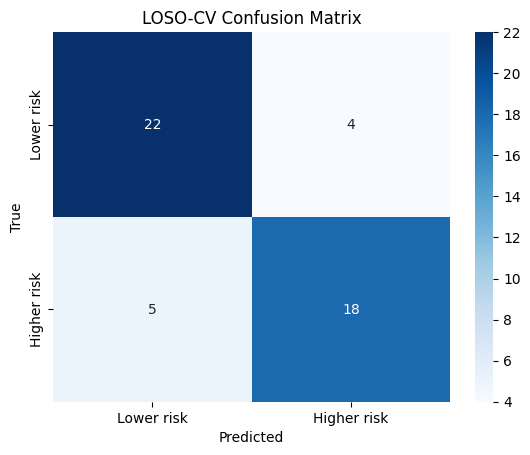


Final Random Forest refit on all 49 Low/High trials for deployment.


In [ ]:
def build_model(name, params):
    if name == "Logistic Regression":
        return LogisticRegression(max_iter=5000, class_weight="balanced", penalty="l1", solver="liblinear", **params)
    return RandomForestClassifier(class_weight="balanced", random_state=42, **params)

logo = LeaveOneGroupOut()

def run_loso_cv(model_name, params):
    preds, trues = [], []
    for train_i, test_i in logo.split(X, y, groups):
        X_tr, X_te = X.iloc[train_i], X.iloc[test_i]
        y_tr, y_te = y.iloc[train_i], y.iloc[test_i]
        fold_scaler = StandardScaler().fit(X_tr)
        m = build_model(model_name, params)
        m.fit(fold_scaler.transform(X_tr), y_tr)
        preds.extend(m.predict(fold_scaler.transform(X_te)))
        trues.extend(y_te)
    return accuracy_score(trues, preds), preds, trues

lr_loso_acc, lr_preds, lr_trues = run_loso_cv("Logistic Regression", lr_grid.best_params_)
rf_loso_acc, rf_preds, rf_trues = run_loso_cv("Random Forest", rf_grid.best_params_)

print(f"Logistic Regression (L1) LOSO-CV accuracy: {lr_loso_acc*100:.2f}%")
print(f"Random Forest LOSO-CV accuracy:             {rf_loso_acc*100:.2f}%")

if lr_loso_acc >= rf_loso_acc:
    best_model_name, best_params = "Logistic Regression", lr_grid.best_params_
    loso_acc, loso_preds, loso_true = lr_loso_acc, lr_preds, lr_trues
else:
    best_model_name, best_params = "Random Forest", rf_grid.best_params_
    loso_acc, loso_preds, loso_true = rf_loso_acc, rf_preds, rf_trues

print(f"\nChosen by LOSO-CV (not a single split): {best_model_name}")
print(classification_report(loso_true, loso_preds, zero_division=0))

cm = confusion_matrix(loso_true, loso_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Lower risk","Higher risk"], yticklabels=["Lower risk","Higher risk"])
plt.ylabel("True"); plt.xlabel("Predicted"); plt.title("LOSO-CV Confusion Matrix")
plt.show()

# Refit the winner on ALL Low/High data for deployment — LOSO already validated generalization.
scaler = StandardScaler().fit(X)
best_model = build_model(best_model_name, best_params)
best_model.fit(scaler.transform(X), y)
print(f"\nFinal {best_model_name} refit on all {len(X)} Low/High trials for deployment.")


## Part 11 — What's Driving the Model


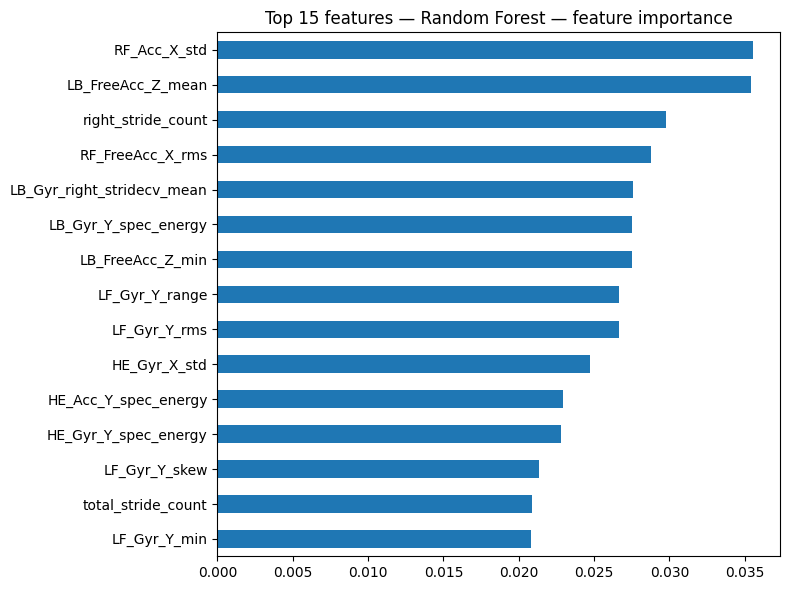

RF_Acc_X_std                  0.035558
LB_FreeAcc_Z_mean             0.035420
right_stride_count            0.029793
RF_FreeAcc_X_rms              0.028783
LB_Gyr_right_stridecv_mean    0.027562
LB_Gyr_Y_spec_energy          0.027527
LB_FreeAcc_Z_min              0.027501
LF_Gyr_Y_range                0.026675
LF_Gyr_Y_rms                  0.026631
HE_Gyr_X_std                  0.024730
HE_Acc_Y_spec_energy          0.022916
HE_Gyr_Y_spec_energy          0.022813
LF_Gyr_Y_skew                 0.021350
total_stride_count            0.020877
LF_Gyr_Y_min                  0.020796
dtype: float64


In [ ]:
if best_model_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    title = "Random Forest — feature importance"
else:
    importances = pd.Series(best_model.coef_[0], index=feature_cols)
    importances = importances[importances != 0]  # L1 zeroed out the rest — only show what survived
    importances = importances.reindex(importances.abs().sort_values(ascending=False).index)
    title = f"Logistic Regression (L1) — {len(importances)} non-zero coefficients, signed magnitude"

importances.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title(f"Top 15 features — {title}")
plt.tight_layout()
plt.show()
print(importances.head(15))


## Part 12 — Save for the Fusion Engine


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/SENSOR DATASET"
joblib.dump(best_model, os.path.join(SAVE_DIR, "oa_sensor_model.pkl"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "oa_sensor_scaler.pkl"))
with open(os.path.join(SAVE_DIR, "oa_sensor_features.json"), "w") as f:
    json.dump(feature_cols, f)

print("Saved model, scaler, and feature list to Drive.")
print(f"\nFinal numbers to report:")
print(f"  Model                          : {best_model_name}")
print(f"  LOSO-CV accuracy (the headline): {loso_acc*100:.2f}%")
print(f"  (Model saved was refit on all {len(X)} Low/High trials, not just the Part 6 training split.)")


Saved model, scaler, and feature list to Drive.

Final numbers to report:
  Model                          : Random Forest
  LOSO-CV accuracy (the headline): 81.63%
  (Model saved was refit on all 49 Low/High trials, not just the Part 6 training split.)


## Part 13 — Scoring the Monitor Tier
The middle-third WOMAC trials never touched training or evaluation. Here we run them through the trained model anyway and look at where they land. If their predicted risk scores cluster near 0.5, that's the model correctly expressing uncertainty on genuinely ambiguous cases — not a gap in the system, but a legitimate third output: **flag for clinical follow-up** rather than a forced guess.


In [ ]:
monitor_data = data[data["tier"] == "Monitor"].copy()

if len(monitor_data):
    monitor_data[feature_cols] = monitor_data[feature_cols].fillna(data_clean[feature_cols].median())
    X_monitor = monitor_data[feature_cols]
    X_monitor_s = scaler.transform(X_monitor)

    if hasattr(best_model, "predict_proba"):
        monitor_data["predicted_risk_score"] = best_model.predict_proba(X_monitor_s)[:, 1]
    else:
        monitor_data["predicted_risk_score"] = best_model.decision_function(X_monitor_s)

    print(f"{len(monitor_data)} Monitor-tier trials from {monitor_data['subject_id'].nunique()} subjects, scored:")
    print(monitor_data[["subject_id", "womac", "predicted_risk_score"]].sort_values("womac").to_string(index=False))
    print(f"\nMean predicted risk score: {monitor_data['predicted_risk_score'].mean():.3f}")
    print(f"Share within 0.15 of the 0.5 boundary: "
          f"{(monitor_data['predicted_risk_score'].sub(0.5).abs() <= 0.15).mean()*100:.0f}%")
    print("\nA cluster near 0.5 here supports the 'flag for follow-up' framing for the deck.")
else:
    print("No Monitor-tier trials found — check the tertile cutoffs in Part 5.")


29 Monitor-tier trials from 7 subjects, scored:
subject_id  womac  predicted_risk_score
     KOA_3   50.0              0.887012
     KOA_3   50.0              0.942699
    KOA_16   53.0              0.757812
    KOA_16   53.0              0.576912
    KOA_16   53.0              0.813862
    KOA_16   53.0              0.888342
    KOA_16   53.0              0.859950
    KOA_16   53.0              0.839734
     KOA_2   53.0              0.672069
     KOA_2   53.0              0.704426
     KOA_2   53.0              0.719591
     KOA_2   53.0              0.683967
    KOA_13   53.0              0.611618
    KOA_13   53.0              0.459255
    KOA_14   53.0              0.571540
    KOA_14   53.0              0.574235
    KOA_17   55.0              0.506432
    KOA_17   55.0              0.489950
    KOA_14   58.0              0.484589
    KOA_14   58.0              0.348573
    KOA_14   58.0              0.352876
    KOA_14   58.0              0.336097
    KOA_14   58.0              0

/tmp/ipykernel_703/110414678.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  monitor_data["predicted_risk_score"] = best_model.predict_proba(X_monitor_s)[:, 1]


## Notes
- If LOSO-CV is still under 80% after this pass, the next highest-leverage moves, in order: **(1)** try per-stride feature aggregation instead of whole-trial stats — compute the same time/frequency features *per gait cycle* using the event boundaries, then aggregate (mean/std) across strides per trial, which is strictly more granular than the current trial-level stride-rhythm features; **(2)** check the feature-importance plot in Part 11 — if Head-sensor features dominate the bottom of the list, drop that sensor's columns entirely and rerun.
- This mirrors your existing pattern from the X-ray and gait modules: feature engineering → subject-level split → compare LR/SVM/RF → pick the winner, evaluated honestly. Keep that consistency for the deck's technical narrative.
- For the deck: report both numbers if you can — the tertile LOSO-CV accuracy as the headline (Low vs. High, confidently classified), and Part 13's Monitor-tier behavior as evidence the system knows what it doesn't know, rather than a silently dropped limitation.
